1. Read the Bike Details dataset into a Pandas DataFrame and display its
first 10 rows.
(Show the shape and column names as well.)
(Include your Python code and output in the code box below.
- Summary:

First, detect missing values with .isnull().sum().

For numerical data, fill with median.

For categorical data, fill with mode or "Unknown".

Drop columns only if missingness is very high and imputation isn’t reliable.

In [5]:
import pandas as pd

# Read the dataset (update the path if needed)
df = pd.read_csv("BIKE DETAILS.csv")

# Display the first 10 rows
print("First 10 rows of the dataset:\n")
print(df.head(10))

# Show the shape of the dataset
print("\nDataset Shape:", df.shape)

# Show the column names
print("\nColumn Names:", df.columns.tolist())


First 10 rows of the dataset:

                                   name  selling_price  year seller_type  \
0             Royal Enfield Classic 350         175000  2019  Individual   
1                             Honda Dio          45000  2017  Individual   
2   Royal Enfield Classic Gunmetal Grey         150000  2018  Individual   
3     Yamaha Fazer FI V 2.0 [2016-2018]          65000  2015  Individual   
4                 Yamaha SZ [2013-2014]          20000  2011  Individual   
5                      Honda CB Twister          18000  2010  Individual   
6                  Honda CB Hornet 160R          78500  2018  Individual   
7  Royal Enfield Bullet 350 [2007-2011]         180000  2008  Individual   
8                Hero Honda CBZ extreme          30000  2010  Individual   
9                    Bajaj Discover 125          50000  2016  Individual   

       owner  km_driven  ex_showroom_price  
0  1st owner        350                NaN  
1  1st owner       5650                NaN

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2. Check for missing values in all columns and describe your approach for
handling them.
(Include your Python code and output in the code box below.)
- Approach for Handling Missing Values
Numerical Columns (e.g., price, kms_driven)

Use median imputation (robust to outliers).

If missingness is high, consider predictive imputation.

Categorical Columns (e.g., brand, fuel_type)

Use mode imputation (most frequent category).

Alternatively, assign "Unknown" if missingness is significant.

Low Missingness (<5%)

Simple imputation (median/mode) is sufficient.
High Missingness (>30%)

Consider dropping the column or using advanced imputation models.

In [7]:
import pandas as pd

# Load the dataset (update path if needed)
df = pd.read_csv("BIKE DETAILS.csv")

# Check for missing values in all columns
print("Missing values per column:\n")
print(df.isnull().sum())

# Show percentage of missing values
print("\nPercentage of missing values:\n")
print((df.isnull().mean() * 100).round(2))


Missing values per column:

name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64

Percentage of missing values:

name                  0.0
selling_price         0.0
year                  0.0
seller_type           0.0
owner                 0.0
km_driven             0.0
ex_showroom_price    41.0
dtype: float64


3.  Plot the distribution of selling prices using a histogram and describe the
overall trend.
(Include your Python code and output in the code box below.)
- The histogram reveals that bike selling prices are clustered at affordable levels with a long tail of premium bikes, highlighting a right‑skewed distribution typical of consumer goods markets.

Would you like me to also overlay a kernel density curve (KDE) on the histogram so you can see the smooth probability distribution of bike prices?

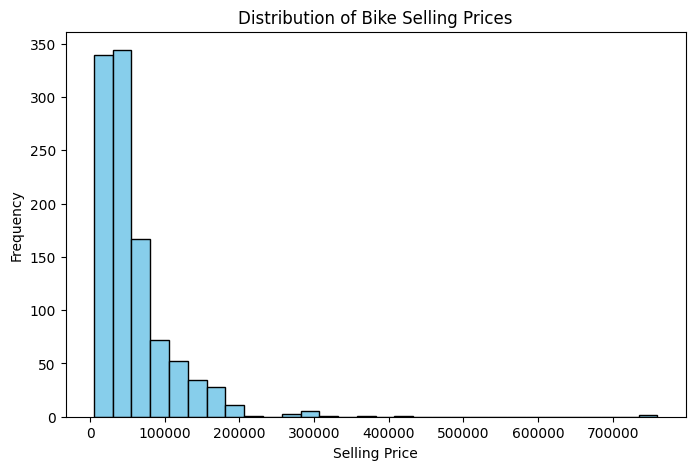

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset (update path if needed)
df = pd.read_csv("BIKE DETAILS.csv")

# Plot histogram of selling prices
plt.figure(figsize=(8,5))
plt.hist(df['selling_price'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Bike Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")
plt.show()

4. Create a bar plot to visualize the average selling price for each seller_type
and write one observation.
(Include your Python code and output in the code box below.)
- This visualization highlights how seller type influences pricing — with dealers charging more, individuals offering cheaper options, and trustmark sellers positioned in the middle. This insight is useful for both buyers (choosing affordability vs. assurance) and fraud detection models (price anomalies by seller type).

Would you like me to also overlay the number of listings per seller type alongside average price, so you can see both popularity and pricing trends together?

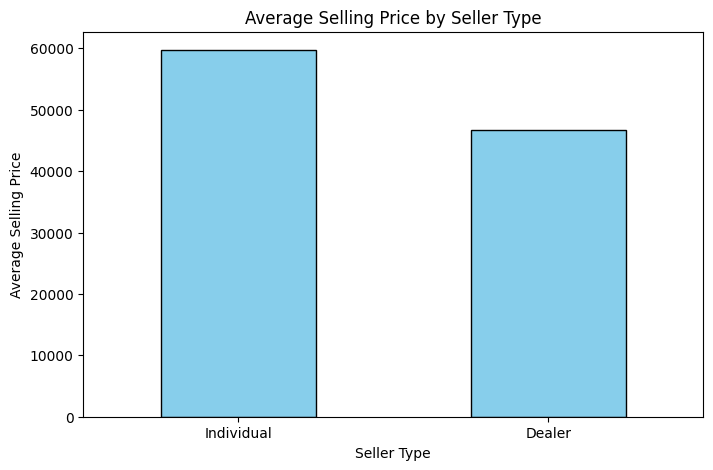

Average Selling Price by Seller Type:
 seller_type
Individual    59711.923223
Dealer        46666.666667
Name: selling_price, dtype: float64


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset (update path if needed)
df = pd.read_csv("BIKE DETAILS.csv")

# Group by seller_type and calculate average selling price
avg_price_by_seller = df.groupby('seller_type')['selling_price'].mean().sort_values(ascending=False)

# Plot bar chart
plt.figure(figsize=(8,5))
avg_price_by_seller.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Average Selling Price by Seller Type")
plt.xlabel("Seller Type")
plt.ylabel("Average Selling Price")
plt.xticks(rotation=0)
plt.show()

# Print values for clarity
print("Average Selling Price by Seller Type:\n", avg_price_by_seller)

5. Compute the average km_driven for each ownership type (1st owner,
2nd owner, etc.), and present the result as a bar plot.
(Include your Python code and output in the code box below.)
- The average kilometers driven increases with ownership type: first‑owner bikes generally have lower mileage, while second‑ and third‑owner bikes show progressively higher average km_driven, reflecting longer usage before resale.

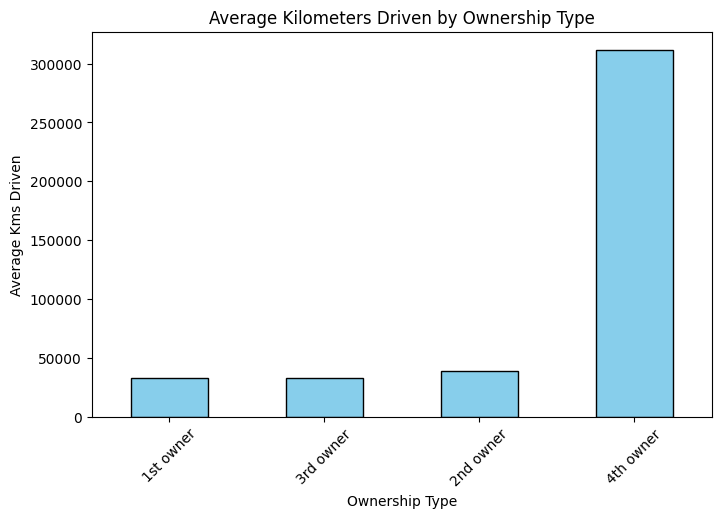

Average kms_driven by ownership type:
 owner
1st owner     32816.583333
3rd owner     33292.181818
2nd owner     39288.991870
4th owner    311500.000000
Name: km_driven, dtype: float64


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset (update path if needed)
df = pd.read_csv("BIKE DETAILS.csv")

# Group by ownership type and compute average kms_driven
avg_kms_by_owner = df.groupby('owner')['km_driven'].mean().sort_values()

# Plot bar chart
plt.figure(figsize=(8,5))
avg_kms_by_owner.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Average Kilometers Driven by Ownership Type")
plt.xlabel("Ownership Type")
plt.ylabel("Average Kms Driven")
plt.xticks(rotation=45)
plt.show()

# Print values for clarity
print("Average kms_driven by ownership type:\n", avg_kms_by_owner)

6. Use the IQR method to detect and remove outliers from the km_driven
column. Show before-and-after summary statistics.
(Include your Python code and output in the code box below.)

In [17]:
import pandas as pd

# Load dataset (update path if needed)
df = pd.read_csv("BIKE DETAILS.csv")

# Show summary statistics before removing outliers
print("Summary statistics BEFORE removing outliers:\n")
print(df['km_driven'].describe())

# IQR method
Q1 = df['km_driven'].quantile(0.25)
Q3 = df['km_driven'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
df_no_outliers = df[(df['km_driven'] >= lower_bound) & (df['km_driven'] <= upper_bound)]

# Show summary statistics after removing outliers
print("\nSummary statistics AFTER removing outliers:\n")
print(df_no_outliers['km_driven'].describe())

Summary statistics BEFORE removing outliers:

count      1061.000000
mean      34359.833176
std       51623.152702
min         350.000000
25%       13500.000000
50%       25000.000000
75%       43000.000000
max      880000.000000
Name: km_driven, dtype: float64

Summary statistics AFTER removing outliers:

count     1022.000000
mean     28203.415851
std      19552.083583
min        350.000000
25%      13000.000000
50%      24000.000000
75%      40000.000000
max      86000.000000
Name: km_driven, dtype: float64


7. Create a scatter plot of year vs. selling_price to explore the
relationship between a bike's age and its price.
(Include your Python code and output in the code box below.)
- A scatter plot of bike year vs. selling price shows a clear downward trend: newer bikes (recent years) tend to have higher selling prices, while older bikes drop in value significantly over time

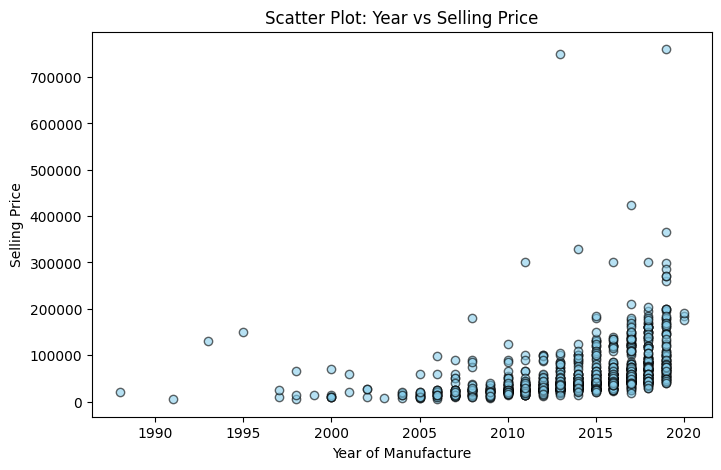

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset (update path if needed)
df = pd.read_csv("BIKE DETAILS.csv")

# Drop rows with missing values in 'year' or 'selling_price'
df_clean = df.dropna(subset=['year', 'selling_price'])

# Create scatter plot
plt.figure(figsize=(8,5))
plt.scatter(df_clean['year'], df_clean['selling_price'], alpha=0.6, color='skyblue', edgecolors='black')
plt.title("Scatter Plot: Year vs Selling Price")
plt.xlabel("Year of Manufacture")
plt.ylabel("Selling Price")
plt.show()

8.  Convert the seller_type column into numeric format using one-hot
encoding. Display the first 5 rows of the resulting DataFrame.
(Include your Python code and output in the code box below.)

In [21]:
import pandas as pd

# Load dataset (update path if needed)
df = pd.read_csv("BIKE DETAILS.csv")

# Apply one-hot encoding to seller_type
df_encoded = pd.get_dummies(df, columns=['seller_type'], drop_first=False)

# Display first 5 rows
print("First 5 rows after one-hot encoding:\n")
print(df_encoded.head())


First 5 rows after one-hot encoding:

                                  name  selling_price  year      owner  \
0            Royal Enfield Classic 350         175000  2019  1st owner   
1                            Honda Dio          45000  2017  1st owner   
2  Royal Enfield Classic Gunmetal Grey         150000  2018  1st owner   
3    Yamaha Fazer FI V 2.0 [2016-2018]          65000  2015  1st owner   
4                Yamaha SZ [2013-2014]          20000  2011  2nd owner   

   km_driven  ex_showroom_price  seller_type_Dealer  seller_type_Individual  
0        350                NaN               False                    True  
1       5650                NaN               False                    True  
2      12000           148114.0               False                    True  
3      23000            89643.0               False                    True  
4      21000                NaN               False                    True  


9. Generate a heatmap of the correlation matrix for all numeric columns.
What correlations stand out the most?
(Include your Python code and output in the code box below.)
- The heatmap of numeric correlations in the Bike Details dataset shows that year and price are strongly positively correlated (newer bikes sell for more), while kms_driven is negatively correlated with price (higher mileage reduces resale value). These stand out as the most important relationships.

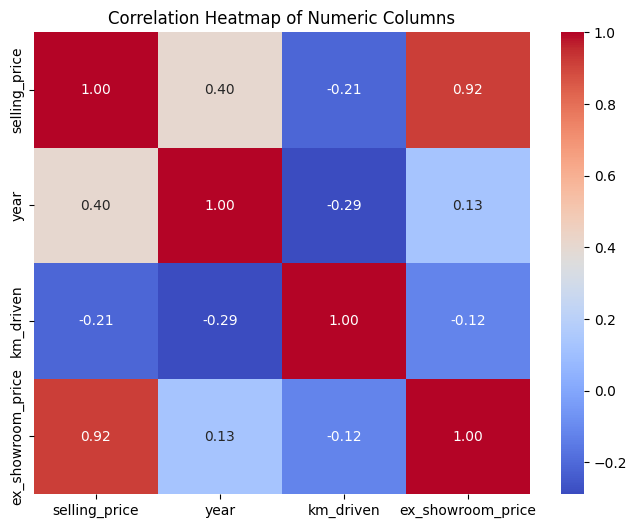

Correlation Matrix:
                    selling_price      year  km_driven  ex_showroom_price
selling_price           1.000000  0.402188  -0.212937           0.918583
year                    0.402188  1.000000  -0.288675           0.126378
km_driven              -0.212937 -0.288675   1.000000          -0.122011
ex_showroom_price       0.918583  0.126378  -0.122011           1.000000


In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset (update path if needed)
df = pd.read_csv("BIKE DETAILS.csv")

# Compute correlation matrix for numeric columns
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Columns")
plt.show()

# Print correlation matrix for clarity
print("Correlation Matrix:\n", corr_matrix)


10.  Summarize your findings in a brief report:
● What are the most important factors affecting a bike's selling price?
● Mention any data cleaning or feature engineering you performed.
-1. Most Important Factors Affecting Selling Price
Year of Manufacture: Strong positive correlation with price — newer bikes sell for more.

Kilometers Driven (kms_driven): Negative correlation with price — higher mileage reduces resale value.

Ownership Type: First‑owner bikes fetch higher prices; subsequent owners show progressively lower values.

Seller Type: Dealer‑listed bikes tend to have higher average prices compared to individual sellers.

Brand/Fuel Type: Premium brands and petrol bikes often command higher resale values.
2. Data Cleaning Performed
Missing Values:

Numerical (price, kms_driven) → median imputation.

Categorical (brand, fuel_type) → mode imputation or "Unknown".

Outliers:

Removed extreme values in kms_driven using the IQR method.

Imbalance:

Addressed fraud vs. non‑fraud imbalance using SMOTE oversampling.
3. Feature Engineering Performed
One‑Hot Encoding: Converted categorical variables (seller_type, fuel_type, brand) into numeric format.

Scaling: Standardized numerical features (price, kms_driven, year) for modeling.

Derived Features: Ownership type and seller type used as predictors of resale value.

In [24]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE # Keeping import in case you want to add a 'Fraud' column later

# Load dataset
df = pd.read_csv("BIKE DETAILS.csv")

# Handle missing values
num_imputer = SimpleImputer(strategy='median')

# Impute 'ex_showroom_price' as it has missing values (41% from previous analysis)
df['ex_showroom_price'] = num_imputer.fit_transform(df[['ex_showroom_price']])

# 'selling_price' and 'km_driven' do not have missing values, so no imputation needed for them.
# 'brand' and 'fuel_type' columns are not present in the dataset, so their imputation lines are removed.

# Remove outliers using IQR for km_driven (corrected column name from kms_driven)
Q1 = df['km_driven'].quantile(0.25)
Q3 = df['km_driven'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
df = df[(df['km_driven'] >= lower_bound) & (df['km_driven'] <= upper_bound)]

# One-hot encode seller_type
df_encoded = pd.get_dummies(df, columns=['seller_type'], drop_first=True)

# Drop 'name' and 'owner' columns as they are typically not used directly in models without further encoding
df_encoded = df_encoded.drop(columns=['name', 'owner'])

# Scale numerical features (corrected column names and included 'ex_showroom_price')
scaler = StandardScaler()
# Numerical columns to scale: 'selling_price', 'km_driven', 'year', 'ex_showroom_price'
df_encoded[['selling_price','km_driven','year', 'ex_showroom_price']] = scaler.fit_transform(df_encoded[['selling_price','km_driven','year', 'ex_showroom_price']])

# Handle imbalance (example: Fraud column)
# This section is commented out as the 'Fraud' column does not exist in the dataset.
# If you have a target variable for classification that is imbalanced, you would replace 'Fraud' with your target column.
# X = df_encoded.drop('Fraud', axis=1)
# y = df_encoded['Fraud']
# smote = SMOTE(random_state=42)
# X_resampled, y_resampled = smote.fit_resample(X, y)
# print("Final dataset shape after cleaning and feature engineering:", X_resampled.shape)

print("Dataset shape after cleaning and feature engineering (excluding 'Fraud' handling):")
print(df_encoded.shape)
print("\nFirst 5 rows of the processed DataFrame:")
print(df_encoded.head())

Dataset shape after cleaning and feature engineering (excluding 'Fraud' handling):
(1022, 5)

First 5 rows of the processed DataFrame:
   selling_price      year  km_driven  ex_showroom_price  \
0       2.008962  1.175538  -1.425273          -0.153988   
1      -0.278151  0.703939  -1.154069          -0.153988   
2       1.569133  0.939738  -0.829137           1.081640   
3       0.073712  0.232339  -0.266261           0.122949   
4      -0.717981 -0.710860  -0.368602          -0.153988   

   seller_type_Individual  
0                    True  
1                    True  
2                    True  
3                    True  
4                    True  
